In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper, BravyiKitaevMapper

In [3]:
atom_string = f"H 0 0 0; H 0 0 {0.25}"

driver = PySCFDriver(
    atom=atom_string,
    basis='sto3g', # Menggunakan dict kustom
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

es_problem = driver.run()
second_q_op = es_problem.hamiltonian.second_q_op()

# mapper = ParityMapper(num_particles=es_problem.num_particles)
mapper = JordanWignerMapper()
# mapper = BravyiKitaevMapper()
qubit_op = mapper.map(second_q_op)

In [9]:
import os
import pandas as pd
import re
def load_all_trains(type_folder, # Jadikan ini argumen wajib atau opsional
                   base_dir='../hasil_eksperimenV17_jw',
                   rel_path=('ml_training', 'predict_data', 'predicted_data_1.csv')):
    
    # Gabungkan base_dir dengan type_folder
    full_base_path = os.path.join(base_dir, type_folder)
    
    # Fungsi pembantu untuk natural sorting
    def natural_key(text):
        return [int(c) if c.isdigit() else c for c in re.split(r'(\d+)', text)]

    dataframes = []
    
    # Pastikan folder ada sebelum listdir
    if not os.path.exists(full_base_path):
        raise FileNotFoundError(f"Folder tidak ditemukan: {full_base_path}")

    dir_list = sorted(os.listdir(full_base_path), key=natural_key)

    for test_dir in dir_list:
        csv_path = os.path.join(full_base_path, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir
            dataframes.append(df)
            
    if not dataframes:
        raise FileNotFoundError(f"Tidak ada file di {full_base_path}")

    full_df = pd.concat(dataframes, ignore_index=True)
    
    # Tetap gunakan categorical agar urutan J-S-1, J-S-2 dst tetap terjaga
    full_df['dataset'] = pd.Categorical(full_df['dataset'], categories=dir_list, ordered=True)
    
    return full_df

In [10]:


def load_all_tests(base_dir='../hasil_eksperimenV17_jw/single',
                   rel_path=('ml_training', 'train_data', 'train_data_1.csv')):
    """
    Membaca semua predicted_data_1.csv dari folder test_*
    dan mengembalikan satu DataFrame besar dengan kolom 'dataset'
    sebagai penanda asal folder (test_01, test_02, dst).
    """
    dataframes = []

    for test_dir in sorted(os.listdir(base_dir)):

        csv_path = os.path.join(base_dir, test_dir, *rel_path)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['dataset'] = test_dir   # penanda asal data
            dataframes.append(df)
        else:
            print(f"Peringatan: file tidak ditemukan: {csv_path}")

    if not dataframes:
        raise FileNotFoundError(
            "Tidak ada file predicted_data_1.csv yang ditemukan di folder test_*"
        )

    return pd.concat(dataframes, ignore_index=True)

In [11]:
import matplotlib.pyplot as plt

# --- 1. PROSES DATA (Dari kode kedua) ---
df_all = load_all_trains(type_folder='single') 
df_all = df_all[~df_all['dataset'].isin(['J-S-1'])]

# Hitung mean absolute error RF per dataset
df_all["pred_abs_err"] = (df_all["RF_energy"] - df_all["ideal_energy"]).abs()
rf_means = df_all.groupby("dataset", observed=True)["pred_abs_err"].mean()

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = load_all_tests()

params = [f'param_{i}' for i in range(12)]
target = 'ideal_energy'
observables = df['observable'].unique()

df["pred_abs_err"] = (df['noisy_energy'] - df["ideal_energy"])**2
df['variance'] = 1-(df[target])**2

# Table to store partial derivative estimates (slopes)
metrik = []


for obs,coeff in qubit_op.to_list():
    
    if obs == 'IIII':
        continue
    
    obs_df = df[df['observable'] == obs]
    dataset_name = obs_df['dataset'].unique()
    dataset_name = dataset_name[0]
    
    # Get the variance of the target column
    variance = (obs_df['variance']).abs().mean()
    variance_weight = (coeff.real*obs_df['variance']).abs().mean()
    L2 = obs_df["pred_abs_err"].sum()
    variansi = obs_df['noisy_energy'].std()
    
    # Get MEA
    Model_MAE = rf_means[dataset_name]
    
    # Optionally store it in your list
    metrik.append({'dataset': dataset_name, 'variance': variance, 'L2 error' : np.sqrt(L2), 'std data': variansi, 
                         'variance weighted': variance_weight, 
                         'Metrik' : variance*np.sqrt(L2),
                         'Model_MAE' : Model_MAE})

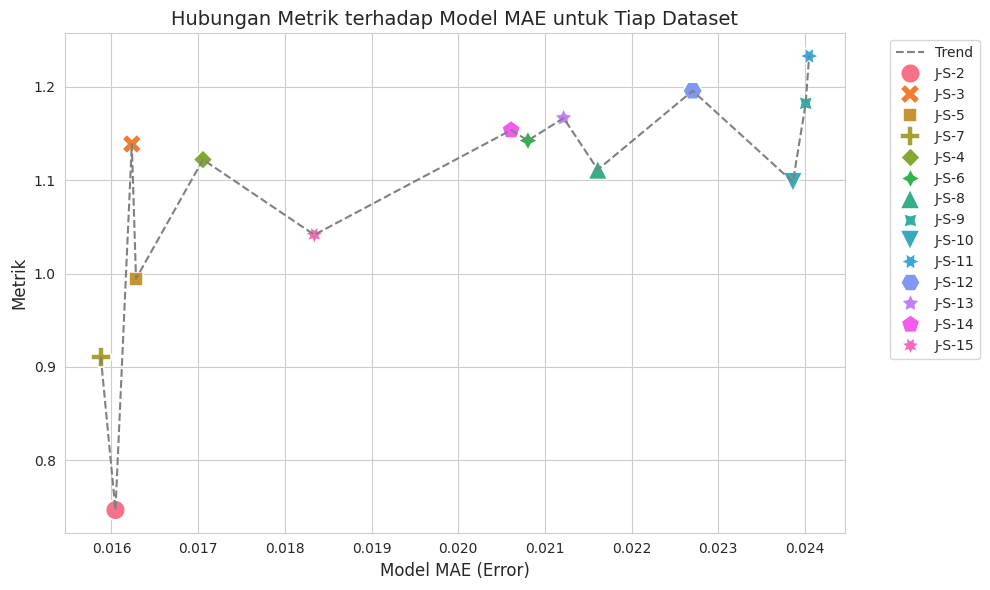

In [13]:
# 1. Ubah list metrik menjadi DataFrame
df_metrik = pd.DataFrame(metrik)

# 2. Plot menggunakan Seaborn
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Menambahkan Line Plot (Garis Tren Umum)
sns.lineplot(
    data=df_metrik, 
    x='Model_MAE', 
    y='Metrik', 
    color='gray', 
    linestyle='--', 
    alpha=1, 
    label='Trend'
)

# Menggunakan scatterplot karena tiap dataset memiliki nilai metrik dan MAE tertentu
plot = sns.scatterplot(
    data=df_metrik, 
    x='Model_MAE', 
    y='Metrik', 
    hue='dataset', 
    style='dataset', 
    s=200  # Ukuran titik
)

# 3. Menambahkan label dan judul
plt.title('Hubungan Metrik terhadap Model MAE untuk Tiap Dataset', fontsize=14)
plt.xlabel('Model MAE (Error)', fontsize=12)
plt.ylabel('Metrik' , fontsize=12)

# Memindahkan legend ke luar jika terlalu banyak dataset
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()